In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from scipy.stats import norm
from scipy.stats import shapiro

import warnings
warnings.filterwarnings('ignore')

# Sampling, Probability Distribution & Central Limit Theorem

## Objective

Apply sampling techniques and probability concepts to analyze the wind turbine dataset and estimate population characteristics using statistical methods.

## Research Questions

1. Can a random sample represent the population?

2. What is the distribution of Wind Speed and Actual Power?

3. Does the sampling distribution become approximately normal as sample size increases?

4. What is the 95% Confidence Interval for the average actual power generation?

In [6]:
df = pd.read_csv("../data/processed/wind_turbine.csv")

print("Shape :", df.shape)

df.head()

Shape : (42781, 13)


,date_time,actual_power_kW,wind_speed_m/s,theoretical_power_kW,wind_direction_deg,month,year,hour,power_delta,eff,season,wind_dir,performance_flag
0,2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904,1,2018,0,36.281117,0.912855,Winter,W,Normal
1,2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113,1,2018,0,66.148316,0.872772,Winter,W,Normal
2,2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789,1,2018,0,84.523429,0.783772,Winter,W,Underperforming
3,2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087,1,2018,0,96.481664,0.813066,Winter,W,Normal
4,2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286,1,2018,0,111.052276,0.774148,Winter,W,Underperforming


## Dataset Overview

In [7]:
print("Columns in Dataset:")

for column in df.columns:
    print("-", column)

Columns in Dataset:
- date_time
- actual_power_kW
- wind_speed_m/s
- theoretical_power_kW
- wind_direction_deg
- month
- year
- hour
- power_delta
- eff
- season
- wind_dir
- performance_flag


## Sampling Analysis

In [8]:
population_mean = df["actual_power_kW"].mean()
population_std = df["actual_power_kW"].std()

print("Population Mean :", round(population_mean, 2))
print("Population Standard Deviation :", round(population_std, 2))

Population Mean : 1544.46
Population Standard Deviation : 1291.89


### Random Sampling

In [9]:
sample_30 = df["actual_power_kW"].sample(
    n=30,
    random_state=42
)

print("Sample Size :", len(sample_30))

sample_30.describe().round(2)

Sample Size : 30


count      30.00
mean     1738.05
std      1409.85
min         0.00
25%       462.68
50%      1287.96
75%      3333.97
max      3604.56
Name: actual_power_kW, dtype: float64

### Compare Sample and Population Statistics

In [10]:
comparison = pd.DataFrame({
    "Statistic": [
        "Mean",
        "Standard Deviation"
    ],
    "Population": [
        population_mean,
        population_std
    ],
    "Sample": [
        sample_30.mean(),
        sample_30.std()
    ]
})


comparison.round(2)

,Statistic,Population,Sample
0,Mean,1544.46,1738.05
1,Standard Deviation,1291.89,1409.85


### Interpretation

The sample mean and standard deviation are close to the population values, indicating that a random sample provides a reasonable representation of the population.

## Probability Distribution

### Wind Speed Distribution

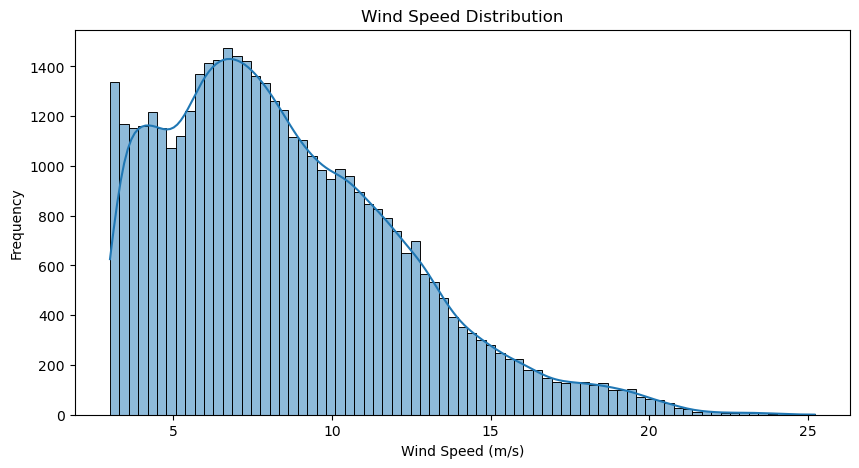

In [11]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["wind_speed_m/s"],
    kde=True
)

plt.title("Wind Speed Distribution")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Frequency")

plt.show()

### Actual Power Distribution

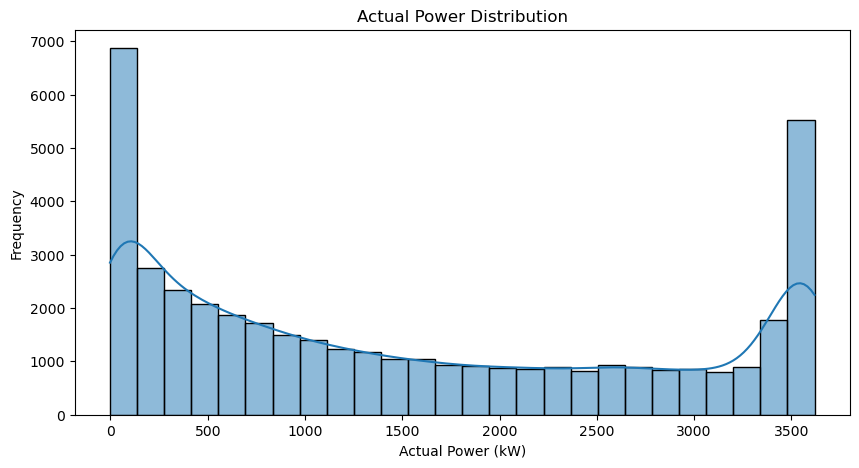

In [12]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["actual_power_kW"],
    kde=True
)

plt.title("Actual Power Distribution")
plt.xlabel("Actual Power (kW)")
plt.ylabel("Frequency")

plt.show()

### Interpretation

- Wind Speed distribution was visualized using a histogram and KDE curve.
- Actual Power distribution was visualized using a histogram and KDE curve.
- These plots help understand the shape and spread of the variables before performing normality assessment.

## Normality Assessment

### Q-Q Plot

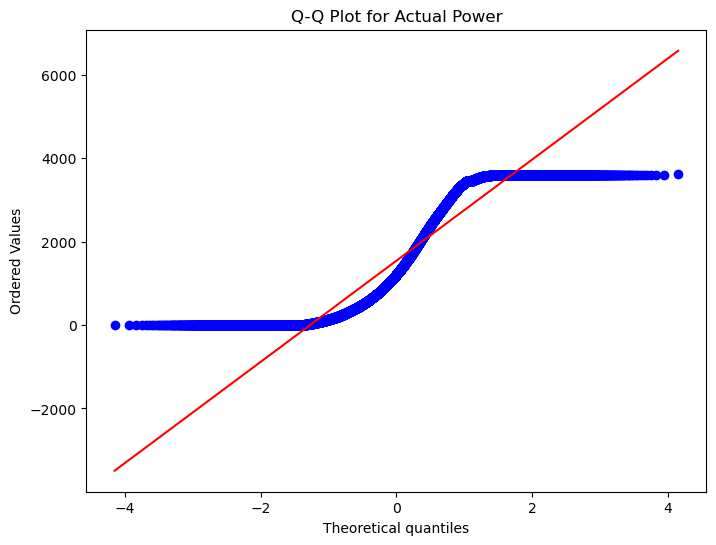

In [13]:
plt.figure(figsize=(8, 6))

stats.probplot(
    df["actual_power_kW"],
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot for Actual Power")

plt.show()

### Interpretation

If the plotted points closely follow the reference line, the data is approximately normally distributed. Large deviations from the line indicate departures from normality.

### Shapiro-Wilk Test

In [14]:
sample_data = df["actual_power_kW"].sample(
    n=5000,
    random_state=42
)

stat, p = shapiro(sample_data)

print("Shapiro Statistic :", round(stat, 4))
print("P-value :", p)

Shapiro Statistic : 0.8795
P-value : 2.1037387912078985e-52


In [15]:
if p > 0.05:
    print("Conclusion : The data appears to be normally distributed.")
else:
    print("Conclusion : The data is not normally distributed.")

Conclusion : The data is not normally distributed.


### Summary

The Q-Q Plot provides a visual assessment of normality, while the Shapiro-Wilk Test provides a statistical assessment. Together, these methods help determine whether the data follows a normal distribution.

## Central Limit Theorem (CLT)

In [14]:
def sampling_distribution(data,
                          sample_size,
                          n_samples=1000):

    means=[]

    for i in range(n_samples):

        sample=np.random.choice(
            data,
            size=sample_size,
            replace=True
        )

        means.append(sample.mean())

    return means

### Generate Sampling Distributions

In [16]:
def sampling_distribution(data, sample_size, n_samples=1000):

    means = []

    for _ in range(n_samples):

        sample = np.random.choice(
            data,
            size=sample_size,
            replace=True
        )

        means.append(sample.mean())

    return means

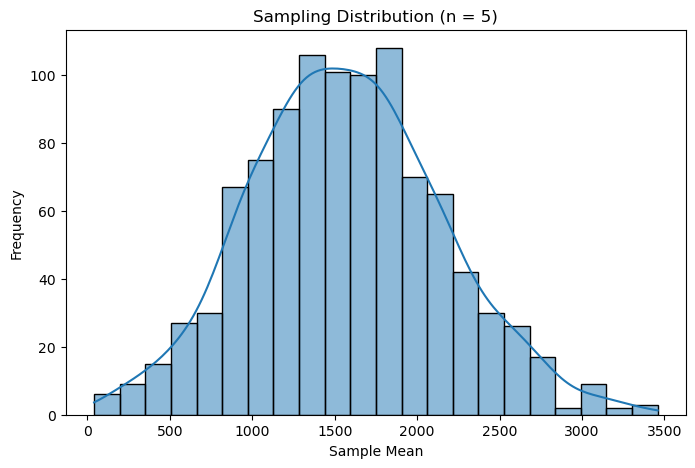

In [17]:
means_5 = sampling_distribution(
    df["actual_power_kW"],
    sample_size=5
)

plt.figure(figsize=(8, 5))

sns.histplot(
    means_5,
    kde=True
)

plt.title("Sampling Distribution (n = 5)")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")

plt.show()

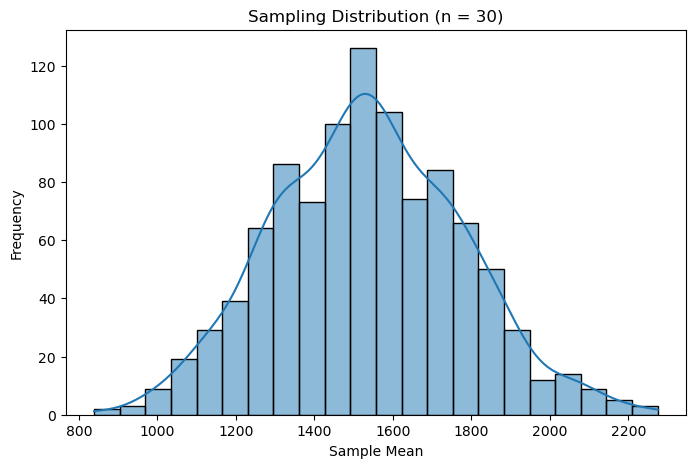

In [18]:
means_30 = sampling_distribution(
    df["actual_power_kW"],
    sample_size=30
)

plt.figure(figsize=(8, 5))

sns.histplot(
    means_30,
    kde=True
)

plt.title("Sampling Distribution (n = 30)")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")

plt.show()

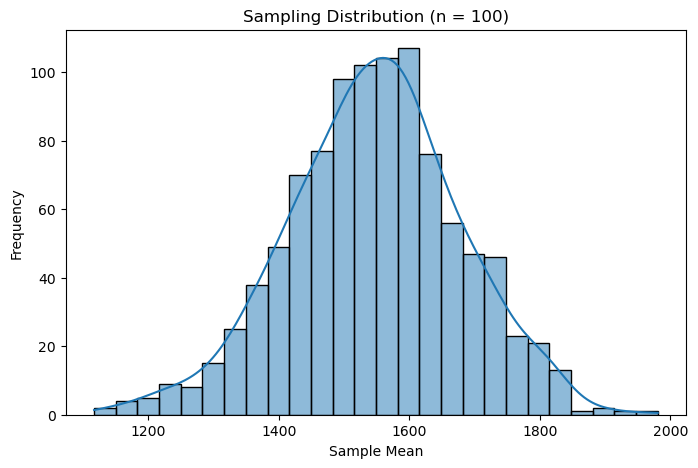

In [19]:
means_100 = sampling_distribution(
    df["actual_power_kW"],
    sample_size=100
)

plt.figure(figsize=(8, 5))

sns.histplot(
    means_100,
    kde=True
)

plt.title("Sampling Distribution (n = 100)")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")

plt.show()

### Interpretation

- For n = 5, the sampling distribution is irregular.
- For n = 30, the distribution becomes more symmetric.
- For n = 100, the distribution closely resembles a normal distribution.

This demonstrates the Central Limit Theorem, which states that the distribution of sample means approaches a normal distribution as the sample size increases.

## Confidence Interval

In [20]:
sample = df["actual_power_kW"].sample(
    n=1000,
    random_state=42
)

mean = sample.mean()
std = sample.std()

n = len(sample)
z = 1.96

margin_error = z * (std / np.sqrt(n))

lower = mean - margin_error
upper = mean + margin_error

print("95% Confidence Interval for Average Actual Power")

print("Sample Mean :", round(mean, 2))
print("Lower Bound :", round(lower, 2))
print("Upper Bound :", round(upper, 2))

95% Confidence Interval for Average Actual Power
Sample Mean : 1602.4
Lower Bound : 1521.27
Upper Bound : 1683.52


### Interpretation

We are 95% confident that the true population mean of the actual power generation lies between the calculated lower and upper confidence limits.Interpretation

## Conclusion

- Random sampling was used to compare sample statistics with population statistics.
- Wind Speed and Actual Power distributions were visualized using histograms.
- Normality was assessed using the Q-Q Plot and the Shapiro-Wilk Test.
- The Central Limit Theorem was demonstrated using sampling distributions with sample sizes of 5, 30, and 100.
- A 95% Confidence Interval was constructed to estimate the population mean of the actual power generation.